# ARTI406 - Machine Learning
# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values or duplicates?
- What patterns exist?
- Which variables influence others?

### Dataset: Jobs and Salaries in Data Science
This dataset contains salary information for data science roles across different
job titles, experience levels, company sizes, and work settings from 2020 to 2023.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**
- Detect errors
- Identify trends
- Discover relationships
- Make data-driven decisions


In [22]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 100


In [23]:
# Load Dataset
df = pd.read_csv("jobs_in_data.csv")

# Display first 5 rows
df.head()


,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M


## Step 1: Data Exploration

### Check Missing Values

In [24]:
# Count missing values per column
print("Missing values per column:")
print(df.isna().sum())
print(f"\nTotal missing values: {df.isna().sum().sum()}")


Missing values per column:
work_year             0
job_title             0
job_category          0
salary_currency       0
salary                0
salary_in_usd         0
employee_residence    0
experience_level      0
employment_type       0
work_setting          0
company_location      0
company_size          0
dtype: int64

Total missing values: 0


### Check Duplicate Rows

In [25]:
# Count duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")


Number of duplicate rows: 4014


### Number of Rows and Columns

In [26]:
print("Shape (rows, columns):", df.shape, "\n")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Shape (rows, columns): (9355, 12) 

Number of rows: 9355
Number of columns: 12


### Data Types of Columns

In [27]:
df.dtypes

,0
work_year,int64
job_title,object
job_category,object
salary_currency,object
salary,int64
salary_in_usd,int64
employee_residence,object
experience_level,object
employment_type,object
work_setting,object


### Descriptive Statistical Summary

In [28]:
df.describe(include='all')

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
count,9355.000000,9355,9355,9355,9355.000000,9355.000000,9355,9355,9355,9355,9355,9355
unique,NaN,125,10,11,NaN,NaN,83,4,4,3,70,3
top,NaN,Data Engineer,Data Science and Research,USD,NaN,NaN,United States,Senior,Full-time,In-person,United States,M
freq,NaN,2195,3014,8591,NaN,NaN,8086,6709,9310,5730,8132,8448
mean,2022.760449,NaN,NaN,NaN,149927.981293,150299.495564,NaN,NaN,NaN,NaN,NaN,NaN
std,0.519470,NaN,NaN,NaN,63608.835387,63177.372024,NaN,NaN,NaN,NaN,NaN,NaN
min,2020.000000,NaN,NaN,NaN,14000.000000,15000.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,2023.000000,NaN,NaN,NaN,105200.000000,105700.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,2023.000000,NaN,NaN,NaN,143860.000000,143000.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,2023.000000,NaN,NaN,NaN,187000.000000,186723.000000,NaN,NaN,NaN,NaN,NaN,NaN


## Step 2: Data Cleaning

### Cleaning Steps Performed

**1. No Missing Values**
The dataset has no missing values, so no imputation was required.

**2. Removing Duplicate Rows**
The dataset contains **4,014 duplicate rows** — exact copies of existing records.
Duplicates can distort analysis results (e.g., inflating counts and skewing averages),
so they must be removed.

**3. Dropping Redundant Columns**
The `salary` and `salary_currency` columns store salaries in each employee's local
currency. Since we have `salary_in_usd` — a standardized, USD-converted version —
the local currency columns are redundant and will be dropped to simplify analysis.


In [29]:
# --- BEFORE CLEANING ---
print("Before Cleaning:")
print(f"  Shape:            {df.shape}")
print(f"  Duplicate rows:   {df.duplicated().sum()}")
print(f"  Columns:          {df.columns.tolist()}")
df.head(3)


Before Cleaning:
  Shape:            (9355, 12)
  Duplicate rows:   4014
  Columns:          ['work_year', 'job_title', 'job_category', 'salary_currency', 'salary', 'salary_in_usd', 'employee_residence', 'experience_level', 'employment_type', 'work_setting', 'company_location', 'company_size']


,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M


In [30]:
# Step 1: Remove duplicate rows
df_clean = df.drop_duplicates()

# Step 2: Drop local-currency salary columns (keeping salary_in_usd)
df_clean = df_clean.drop(columns=['salary', 'salary_currency'])

# Step 3: Reset index
df_clean = df_clean.reset_index(drop=True)

# --- AFTER CLEANING ---
print("After Cleaning:")
print(f"  Shape:            {df_clean.shape}")
print(f"  Duplicate rows:   {df_clean.duplicated().sum()}")
print(f"  Columns:          {df_clean.columns.tolist()}")
df_clean.head(3)


After Cleaning:
  Shape:            (5341, 10)
  Duplicate rows:   0
  Columns:          ['work_year', 'job_title', 'job_category', 'salary_in_usd', 'employee_residence', 'experience_level', 'employment_type', 'work_setting', 'company_location', 'company_size']


,work_year,job_title,job_category,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,81800,United States,Senior,Full-time,In-person,United States,M


## Step 3: Univariate Analysis

Univariate analysis examines **one variable at a time** to understand
its distribution, spread, and most frequent values.


### Plot 1: Distribution of Salary in USD (Histogram)
**Why this plot?**
A histogram with a KDE curve reveals how salaries are distributed across the dataset —
whether they are normally spread or skewed — and where most salaries are concentrated.


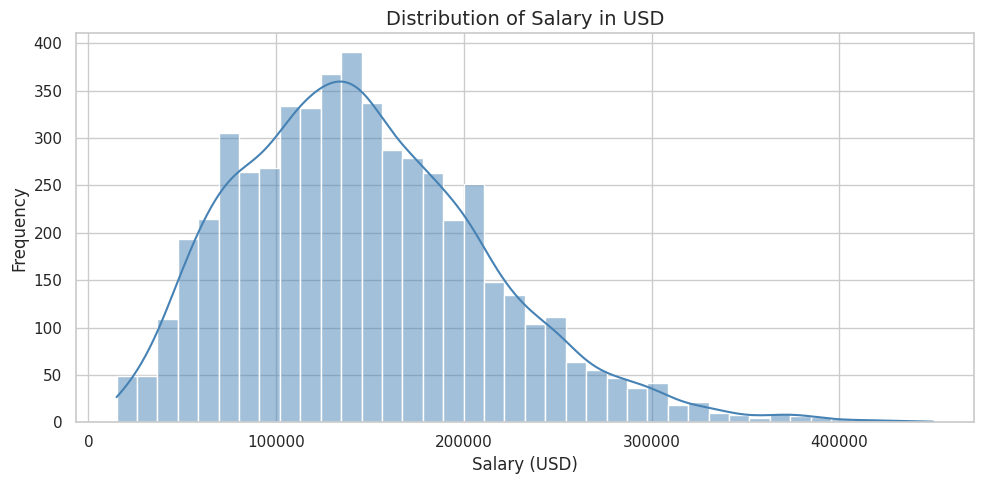

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['salary_in_usd'], bins=40, color='steelblue', kde=True)
plt.title("Distribution of Salary in USD", fontsize=14)
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**Insight:**
The salary distribution is **right-skewed**, with most data science professionals
earning between \$50,000 and \$200,000 USD. A small number of very high earners
pull the tail to the right. The median salary is a more reliable central measure
than the mean due to this skew.


### Plot 2: Number of Jobs by Experience Level (Bar Chart)
**Why this plot?**
A bar chart clearly shows the count of job records for each experience level,
revealing the composition of the dataset.


/tmp/ipykernel_2404/2004187840.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exp_counts.index, y=exp_counts.values, palette='Blues_d')


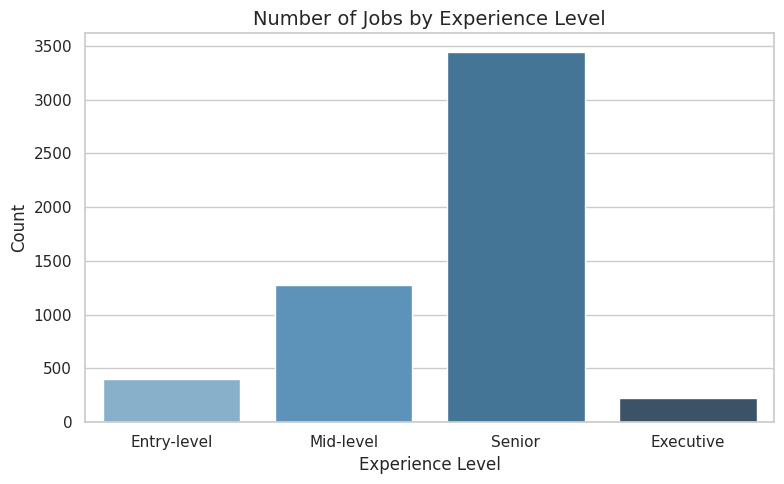

In [32]:
exp_order = ['Entry-level', 'Mid-level', 'Senior', 'Executive']
exp_counts = df_clean['experience_level'].value_counts().reindex(exp_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=exp_counts.index, y=exp_counts.values, palette='Blues_d')
plt.title("Number of Jobs by Experience Level", fontsize=14)
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**Insight:**
Senior-level roles dominate the dataset, followed by Mid-level positions.
Executive and Entry-level roles are far less represented. This suggests the
dataset skews toward experienced professionals, which should be considered
when interpreting salary averages.


### Plot 3: Most Common Job Categories (Horizontal Bar Chart)
**Why this plot?**
A horizontal bar chart is ideal when there are many categories to compare,
preventing label crowding while making ranking easy to read.


/tmp/ipykernel_2404/1912711254.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')


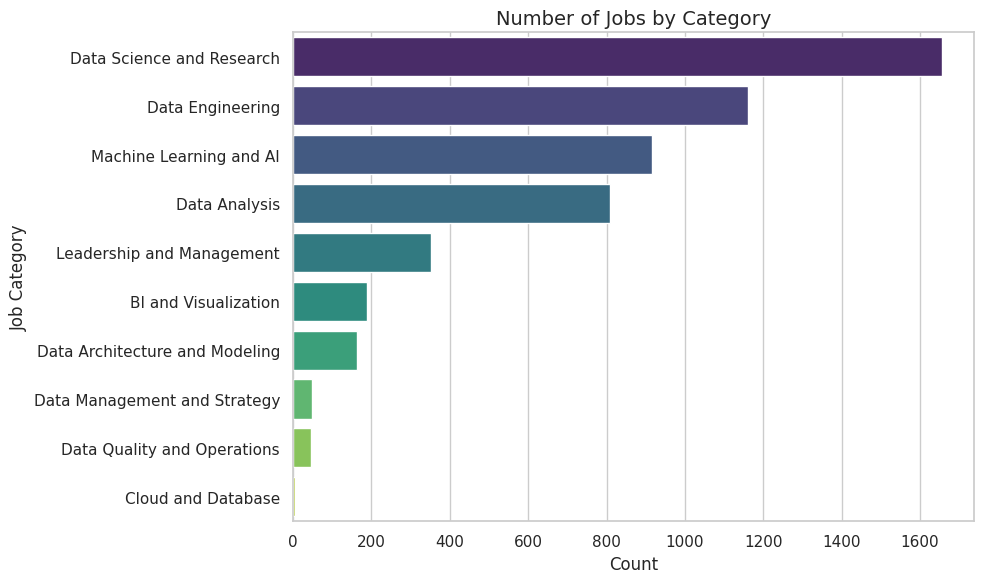

In [33]:
cat_counts = df_clean['job_category'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
plt.title("Number of Jobs by Category", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Job Category")
plt.tight_layout()
plt.show()


**Insight:**
Data Engineering and Data Science are the most represented job categories,
reflecting high market demand. ML & AI also appears prominently, consistent
with the rapid adoption of machine learning across industries.


## Step 4: Bivariate Analysis

Bivariate analysis explores the **relationship between two variables** at a time,
helping us understand what factors influence salary.


### Plot 4: Average Salary by Experience Level (Bar Chart)
**Why this plot?**
Comparing average salaries across experience levels directly answers:
does more experience lead to higher pay?


/tmp/ipykernel_2404/1433140905.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary_exp.index, y=avg_salary_exp.values, palette='Blues_d')


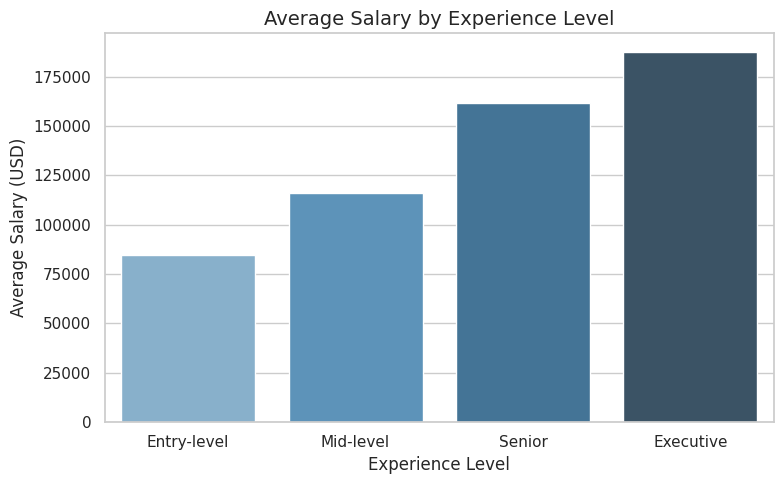

In [34]:
exp_order = ['Entry-level', 'Mid-level', 'Senior', 'Executive']
avg_salary_exp = df_clean.groupby('experience_level')['salary_in_usd'].mean().reindex(exp_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_salary_exp.index, y=avg_salary_exp.values, palette='Blues_d')
plt.title("Average Salary by Experience Level", fontsize=14)
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.tight_layout()
plt.show()


**Insight:**
There is a clear and strong **positive relationship** between experience and salary.
The jump from Mid-level to Senior, and especially to Executive, is substantial —
confirming that career progression in data science brings meaningful financial reward.


### Plot 5: Top 10 Highest Paying Job Titles (Horizontal Bar Chart)
**Why this plot?**
Ranking job titles by average salary reveals which specific roles command
the highest compensation in the data science field.


/tmp/ipykernel_2404/1034199478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette='magma')


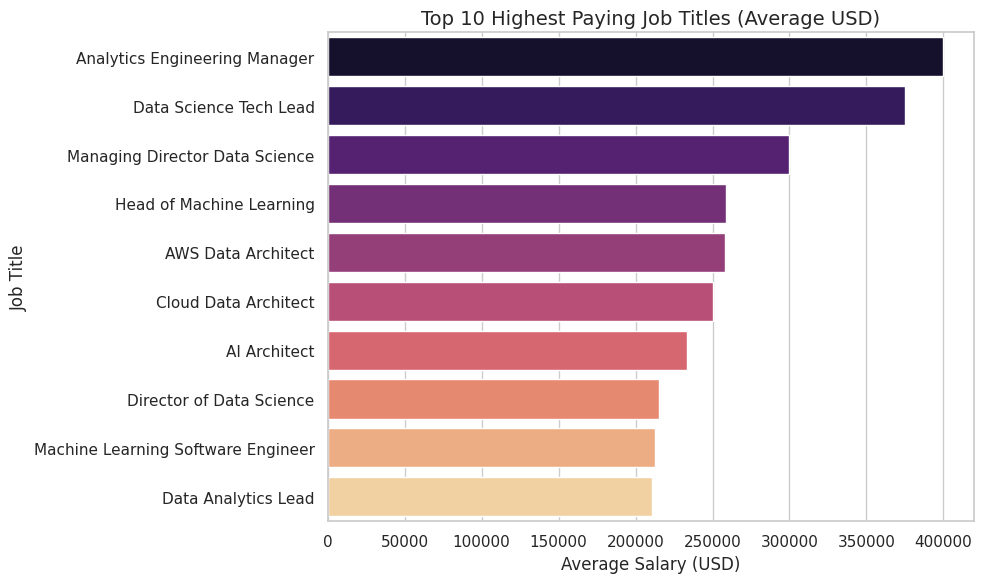

In [35]:
top_titles = (df_clean.groupby('job_title')['salary_in_usd']
              .mean()
              .sort_values(ascending=False)
              .head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_titles.values, y=top_titles.index, palette='magma')
plt.title("Top 10 Highest Paying Job Titles (Average USD)", fontsize=14)
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()


**Insight:**
Highly specialized roles — such as Research Scientists, AI Architects, and
Principal Data Engineers — earn the highest average salaries. These positions
require deep, niche expertise that commands a significant premium over
more generalist data roles.


### Plot 6: Salary Distribution by Work Setting (Box Plot)
**Why this plot?**
A box plot shows the full spread and central tendency of salaries for each
work setting (Remote, Hybrid, In-person), making it easy to compare groups
and spot outliers.


/tmp/ipykernel_2404/265307963.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='work_setting', y='salary_in_usd', data=df_clean, palette='Set2')


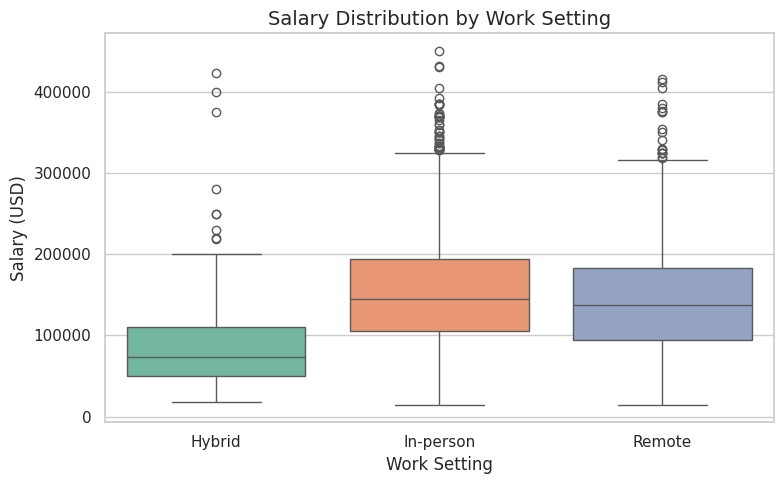

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='work_setting', y='salary_in_usd', data=df_clean, palette='Set2')
plt.title("Salary Distribution by Work Setting", fontsize=14)
plt.xlabel("Work Setting")
plt.ylabel("Salary (USD)")
plt.tight_layout()
plt.show()


**Insight:**
Remote workers tend to have slightly higher median salaries compared to
In-person and Hybrid workers. However, all three groups overlap considerably,
suggesting work setting alone is not the dominant salary predictor.
The Remote category also shows more high-salary outliers.


### Plot 7: Salary Distribution by Company Size (Box Plot)
**Why this plot?**
A box plot comparing salaries across Small, Medium, and Large companies
reveals whether company size plays a role in compensation.


/tmp/ipykernel_2404/1976453012.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='company_size', y='salary_in_usd', data=df_clean,


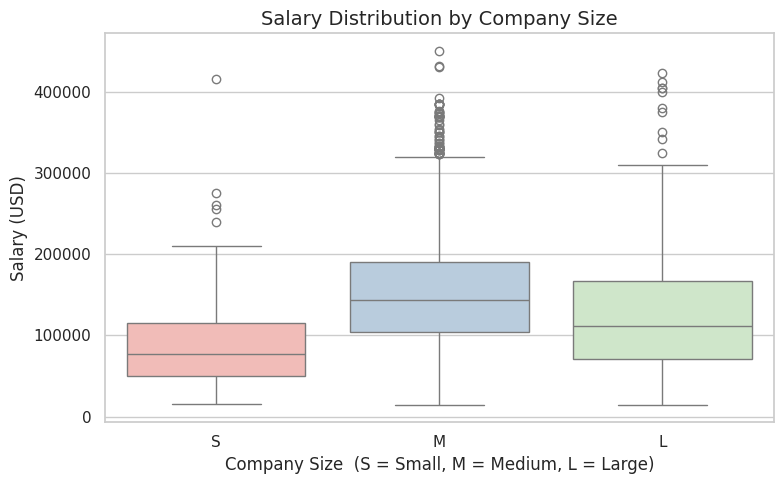

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='company_size', y='salary_in_usd', data=df_clean,
            order=['S', 'M', 'L'], palette='Pastel1')
plt.title("Salary Distribution by Company Size", fontsize=14)
plt.xlabel("Company Size  (S = Small, M = Medium, L = Large)")
plt.ylabel("Salary (USD)")
plt.tight_layout()
plt.show()


**Insight:**
Medium and Large companies generally offer higher salaries than Small companies.
Medium companies show the widest salary range, suggesting greater role diversity
within that category. Small companies tend to have lower and more consistent salaries,
likely reflecting tighter budgets.


### Plot 8: Correlation Matrix (Heatmap)
**Why this plot?**
A correlation heatmap quantifies linear relationships between numerical variables,
helping identify which features are related before building predictive models.


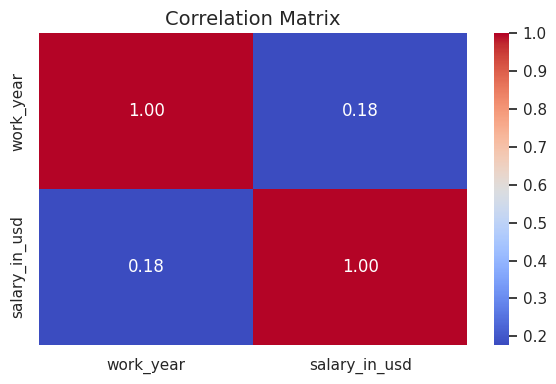

In [38]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_clean[['work_year', 'salary_in_usd']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()


**Insight:**
There is a **weak positive correlation** between work year and salary in USD,
suggesting salaries have been gradually rising over time. The correlation is not
strong, however — meaning experience level, job title, and company size are
likely more influential factors in determining salary.


## Step 5: Time-Based Analysis

### Plot 9: Average Salary Trend by Year (Line Chart)
**Why this plot?**
A line chart is the most intuitive way to visualize change over time,
making salary growth trends immediately clear.


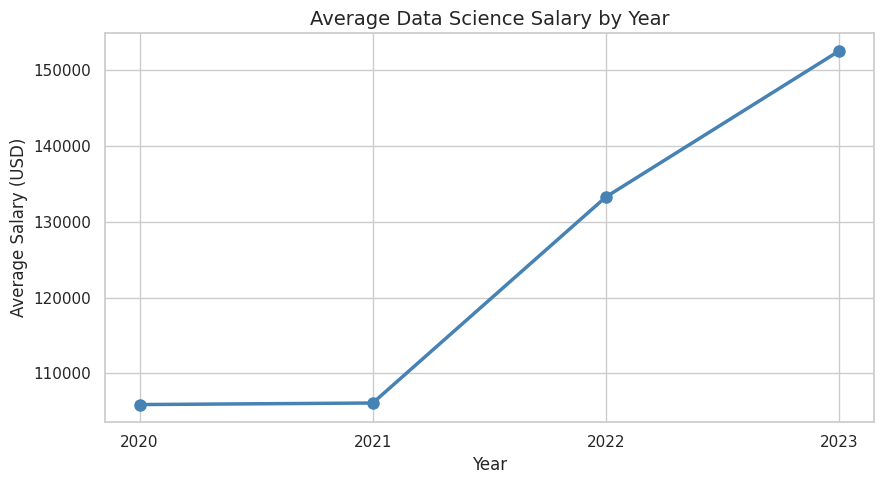

In [39]:
avg_salary_year = df_clean.groupby('work_year')['salary_in_usd'].mean()

plt.figure(figsize=(9, 5))
avg_salary_year.plot(marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.title("Average Data Science Salary by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")
plt.xticks(avg_salary_year.index)
plt.tight_layout()
plt.show()


**Insight:**
Average data science salaries have shown a **consistent upward trend** from 2020 to 2023.
The sharpest increase occurred between 2021 and 2022, likely driven by a tech hiring boom
and intense competition for data talent. This trend confirms data science as a growing,
well-compensated field.


### Plot 10: Work Setting Distribution Over the Years (Stacked Bar Chart)
**Why this plot?**
A stacked bar chart shows how the proportion of Remote, Hybrid, and In-person
roles changed each year — an important trend following the COVID-19 pandemic.


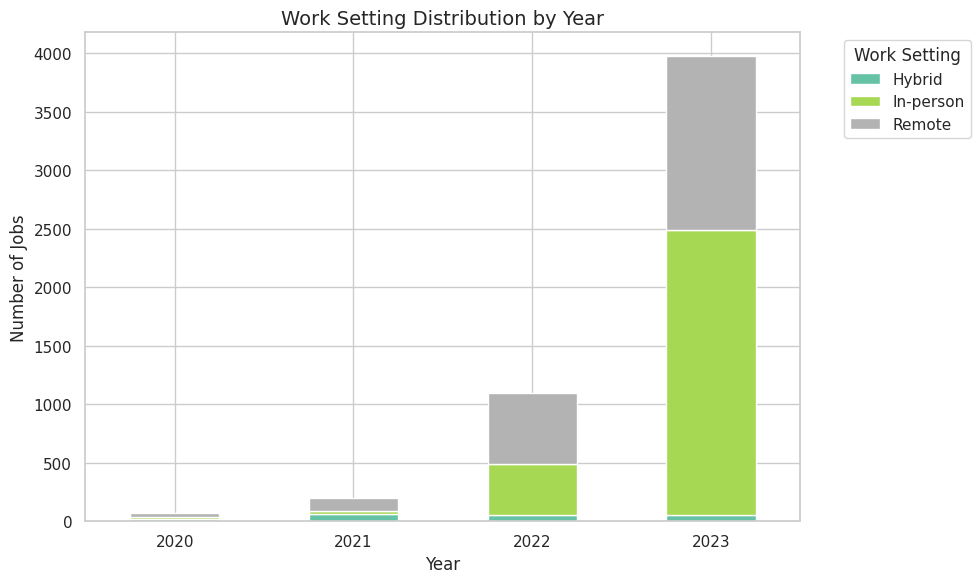

In [40]:
setting_year = (df_clean.groupby(['work_year', 'work_setting'])
                .size()
                .unstack(fill_value=0))

setting_year.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title("Work Setting Distribution by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Jobs")
plt.legend(title="Work Setting", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:**
Remote work grew sharply in 2021 and 2022, consistent with the global pandemic-driven
shift to distributed work. By 2023, there is a visible increase in In-person and Hybrid
roles, reflecting companies gradually returning employees to offices. Despite this,
Remote work remains a substantial share of data science positions.


## Summary of Key Insights

Through this Exploratory Data Analysis of the **Jobs and Salaries in Data Science** dataset,
the following key findings were identified:

1. **Salary Distribution**: Data science salaries are right-skewed. Most professionals earn between \$50,000–\$200,000 USD, with a small number of very high earners.
2. **Experience Matters**: There is a strong positive relationship between experience level and salary. Executive roles earn dramatically more than entry-level positions.
3. **Top Roles**: Specialized roles like Research Scientists and AI Architects command the highest average salaries, reflecting premium demand for deep expertise.
4. **Work Setting**: Remote workers tend to earn slightly more, though the differences across settings are not dramatic and there is significant overlap.
5. **Company Size**: Medium and large companies generally offer higher compensation than small companies.
6. **Salary Growth**: Average data science salaries increased steadily from 2020 to 2023, with the sharpest rise between 2021 and 2022.
7. **Remote Work Trend**: Remote work surged after 2020 and remained dominant through 2022, but shows signs of gradual decline in 2023 as in-person arrangements return.

This dataset provides a strong foundation for building salary prediction models in future assignments.
